#Requirements + Data Reading

In [1]:

!pip install "matplotlib>=3.8,<4" "numpy>=1.26,<3" "pandas>=2.0,<3"
import pandas as pd

from google.colab import drive

drive.mount ('/content/drive')

DATA=pd.read_csv("/content/drive/MyDrive/train-test.csv",sep=',')


Mounted at /content/drive


#EDA

In [2]:
DATA

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [3]:
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [4]:
DATA.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [5]:
DATA.duplicated().sum()

np.int64(0)

In [6]:
DATA.nunique()

,0
load_id,48000
pickup,64
delivery,64
pickup_lat,64
pickup_lon,63
delivery_lat,64
delivery_lon,63
distance,21204
equipment,3
weight,23678


In [7]:
DATA.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [8]:
print(DATA.duplicated().sum())
print(DATA['load_id'].duplicated().sum())
print(DATA.isna().sum())
print(DATA['pickup'].nunique())
print(DATA['delivery'].nunique())
print(DATA['equipment'].unique())

0
0
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64
64
64
['Dry Van' 'Reefer' 'Flatbed']


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
DATA['posted_rate'].skew()

np.float64(1.9023948792201815)

<Axes: xlabel='posted_rate', ylabel='Count'>

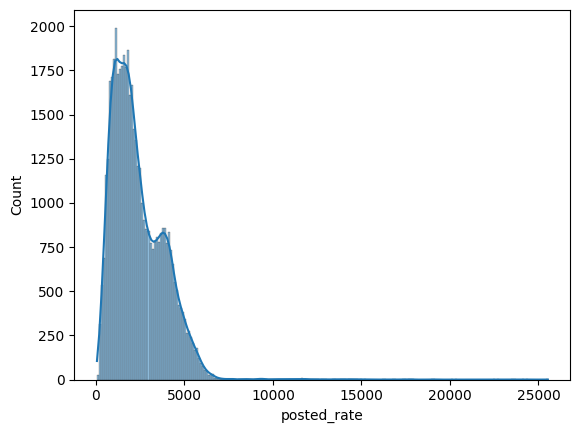

In [11]:
sns.histplot(DATA['posted_rate'], kde=True)

<Axes: ylabel='posted_rate'>

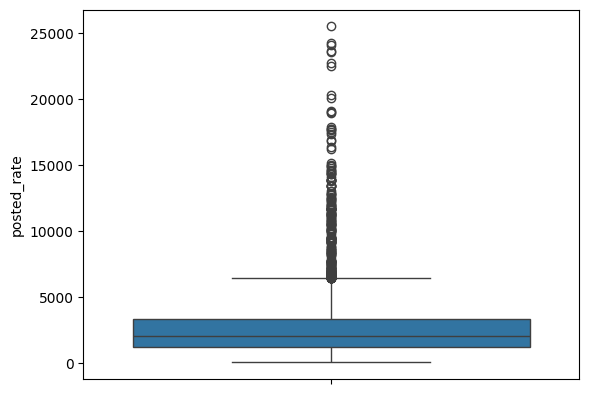

In [12]:
sns.boxplot(DATA['posted_rate'])

<Axes: xlabel='weight', ylabel='Count'>

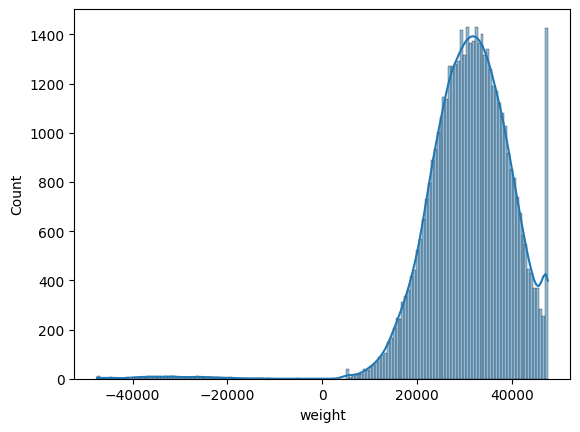

In [13]:
sns.histplot(DATA['weight'], kde=True)

<Axes: xlabel='market_index', ylabel='Count'>

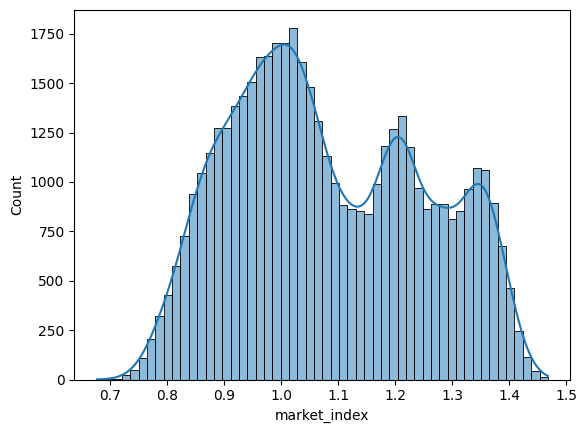

In [14]:
sns.histplot(DATA['market_index'], kde=True)

In [15]:
df=DATA.select_dtypes(include=['number'])

In [16]:
df.corr()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
pickup_lat,1.000000,0.559208,-0.008283,-0.006143,-0.077742,0.001898,-0.001735,-0.004181,-0.090873
pickup_lon,0.559208,1.000000,-0.008609,-0.012231,-0.273411,0.006603,0.001432,0.013659,-0.255058
delivery_lat,-0.008283,-0.008609,1.000000,0.557083,-0.080646,-0.004243,-0.002587,-0.002708,-0.091970
delivery_lon,-0.006143,-0.012231,0.557083,1.000000,-0.275657,-0.001144,-0.008487,0.011437,-0.257086
distance,-0.077742,-0.273411,-0.080646,-0.275657,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.001898,0.006603,-0.004243,-0.001144,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.001735,0.001432,-0.002587,-0.008487,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.004181,0.013659,-0.002708,0.011437,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,-0.090873,-0.255058,-0.091970,-0.257086,0.908519,0.034840,0.034165,-0.039858,1.000000


                mean    median  count
month                                
2025-01  2255.967048  1915.200   4918
2025-02  2273.804801  1994.250   4337
2025-03  2372.268092  2022.920   5036
2025-04  2372.162308  2044.240   4819
2025-05  2421.776342  2065.510   4913
2025-06  2497.030115  2120.220   4783
2025-07  2415.162030  2059.145   4912
2025-08  2338.407661  2015.730   4759
2025-09  2406.374013  2057.130   4670
2025-10  2379.051374  2035.900   4853


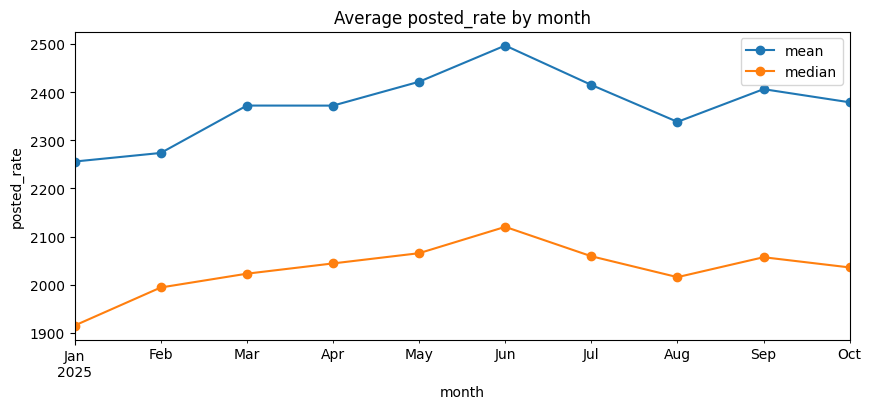

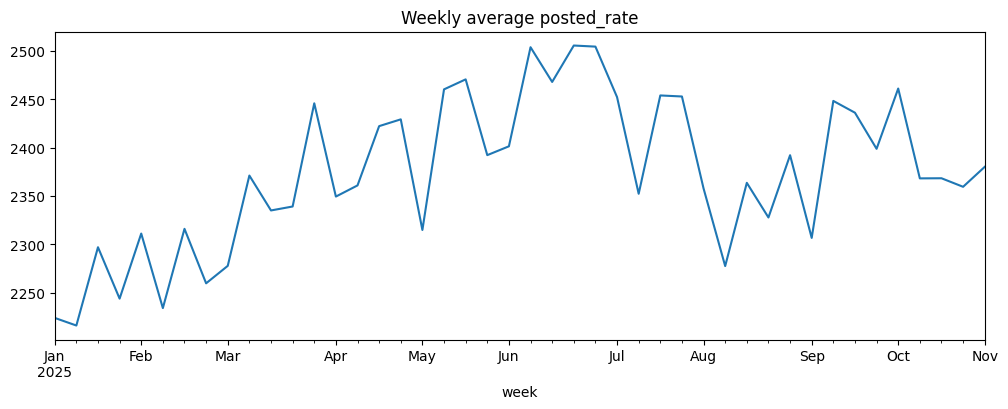

In [17]:

DATA['date'] = pd.to_datetime(DATA['date'])
DATA['month'] = DATA['date'].dt.to_period('M')
DATA['week'] = DATA['date'].dt.to_period('W')

# Monthly average
monthly = DATA.groupby('month')['posted_rate'].agg(['mean', 'median', 'count'])
print(monthly)

fig, ax = plt.subplots(figsize=(10,4))
monthly['mean'].plot(ax=ax, marker='o', label='mean')
monthly['median'].plot(ax=ax, marker='o', label='median')
ax.set_ylabel('posted_rate')
ax.set_title('Average posted_rate by month')
ax.legend()
plt.show()

# Weekly, finer-grained
weekly = DATA.groupby('week')['posted_rate'].mean()
weekly.plot(figsize=(12,4), title='Weekly average posted_rate')
plt.show()

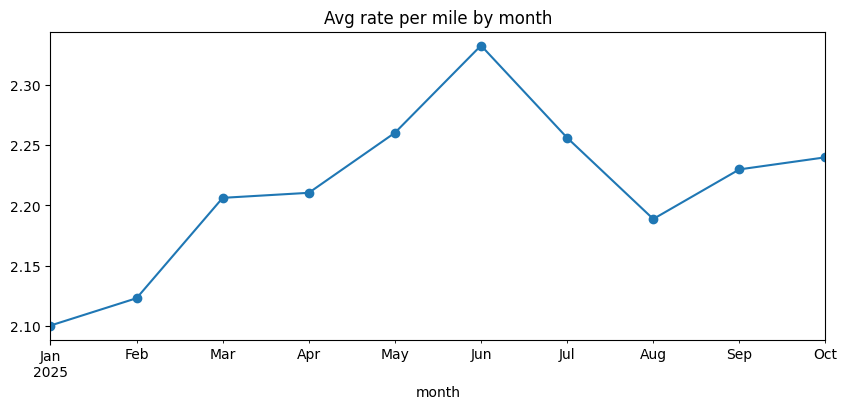

In [18]:
DATA['rate_per_mile'] = DATA['posted_rate'] / DATA['distance']
DATA.groupby('month')['rate_per_mile'].mean().plot(marker='o', figsize=(10,4), title='Avg rate per mile by month')
plt.show()

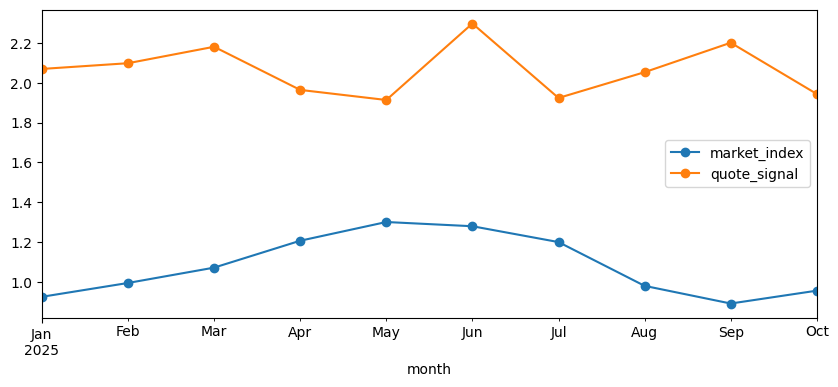

In [19]:
DATA.groupby('month')[['market_index','quote_signal']].mean().plot(figsize=(10,4), marker='o')
plt.show()

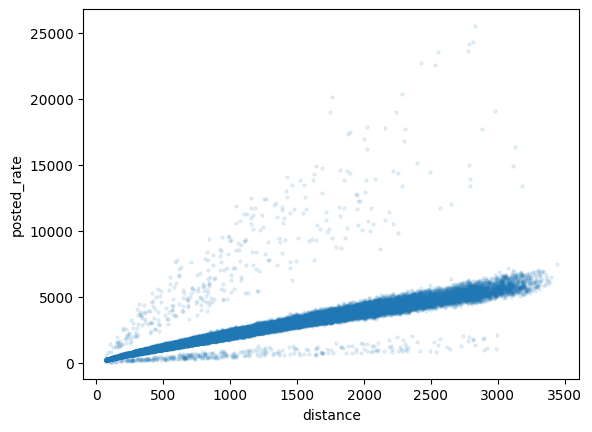

In [20]:
plt.scatter(DATA['distance'], DATA['posted_rate'], alpha=0.1, s=5)
plt.xlabel('distance'); plt.ylabel('posted_rate')
plt.show()

In [21]:
DATA[['distance','weight','market_index','quote_signal','posted_rate']].corr()

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.034840,0.034165,-0.039858,1.000000


In [22]:
zero_weight = DATA[DATA['weight'] <= 0]
print(zero_weight.shape)
print(zero_weight[['distance', 'equipment', 'posted_rate']].describe())
zero_weight['equipment'].value_counts()

(292, 17)
          distance   posted_rate
count   292.000000    292.000000
mean   1120.920205   2389.786233
std     733.132047   1641.761285
min      75.100000    247.370000
25%     531.975000   1257.410000
50%     930.450000   1994.960000
75%    1537.125000   3185.257500
max    3161.700000  14561.210000


,count
equipment,
Dry Van,155
Flatbed,70
Reefer,67


In [23]:
# Treat non-positive weight as missing, same as true NaNs
DATA.loc[DATA['weight'] <= 0, 'weight'] = np.nan

# Confirm total missing now
print(DATA['weight'].isna().sum())

# Impute with median (same approach as before)
weight_median = DATA['weight'].median()
DATA['weight'] = DATA['weight'].fillna(weight_median)

592


In [24]:
(DATA[['distance','weight','posted_rate']] <= 0).sum()


,0
distance,0
weight,0
posted_rate,0


In [25]:

DATA['equipment'].value_counts(normalize=True)

,proportion
equipment,
Dry Van,0.566708
Reefer,0.250937
Flatbed,0.182354


In [26]:
DATA['pickup'].nunique(), DATA['delivery'].nunique()

(64, 64)

#Data PreProc

In [27]:
DATA['market_index'] = DATA['market_index'].fillna(DATA['market_index'].mean())

In [28]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical column 'equipment' from DATA

encoded_array = ohe.fit_transform(DATA[['equipment']])

# Convert encoded array back into a DataFrame with readable column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(['equipment']),
    index=DATA.index, # Ensure index alignment
    dtype=int
)

# Combine the encoded columns back with the numerical features
# Drop the original 'equipment' column from DATA before concatenating
df_no_equipment = DATA.drop(columns=['equipment'])
df_sklearn = pd.concat([df_no_equipment, encoded_df], axis=1)



In [29]:
df_sklearn.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,week,rate_per_mile,equipment_Dry Van,equipment_Flatbed,equipment_Reefer
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,645.41,2025-01,2024-12-30/2025-01-05,2.352935,1,0,0
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,679.97,2025-01,2024-12-30/2025-01-05,2.424135,0,0,1
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,1802.54,2025-01,2024-12-30/2025-01-05,1.862513,1,0,0
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,1827.28,2025-01,2024-12-30/2025-01-05,1.892770,1,0,0
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,1380.28,2025-01,2024-12-30/2025-01-05,2.547112,0,0,1


In [30]:
df_sklearn.drop(columns=['pickup', 'delivery', 'pickup_lat','pickup_lon', 'delivery_lat', 'delivery_lon','week','rate_per_mile'], inplace=True)


In [31]:
df_sklearn.set_index('load_id',inplace=True)

In [32]:
df_sklearn['date'] = pd.to_datetime(df_sklearn['date'])
df_sklearn['day_of_week'] = df_sklearn['date'].dt.dayofweek
df_sklearn['days_since_start'] = (df_sklearn['date'] - pd.Timestamp('2025-01-01')).dt.days
df_sklearn['month'] = df_sklearn['date'].dt.month

In [33]:
df_sklearn[['date', 'month', 'day_of_week', 'days_since_start']].head()

,date,month,day_of_week,days_since_start
load_id,,,,
TR-000001,2025-01-01,1,2,0
TR-000002,2025-01-01,1,2,0
TR-000003,2025-01-01,1,2,0
TR-000004,2025-01-01,1,2,0
TR-000005,2025-01-01,1,2,0


In [34]:
df_sklearn.drop(columns=['date'], inplace=True)

In [35]:
df_sklearn

,distance,weight,market_index,quote_signal,posted_rate,month,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,day_of_week,days_since_start
load_id,,,,,,,,,,,
TR-000001,274.3,30658.0,0.95684,2.39595,645.41,1,1,0,0,2,0
TR-000002,280.5,17555.0,0.97623,2.43355,679.97,1,0,0,1,2,0
TR-000003,967.8,31721.0,1.00971,1.84491,1802.54,1,1,0,0,2,0
TR-000004,965.4,32333.0,0.94518,1.87712,1827.28,1,1,0,0,2,0
TR-000005,541.9,35183.0,0.98480,2.56300,1380.28,1,0,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...
TR-047996,1830.9,31786.0,0.98865,2.05626,3787.32,10,0,1,0,4,303
TR-047997,445.8,37465.0,1.03034,1.51985,1171.93,10,0,0,1,4,303
TR-047998,267.9,24528.0,1.00846,1.46954,713.36,10,0,1,0,4,303


# Data Split Approach

In [36]:
# Sort chronologically
df_sklearn = df_sklearn.sort_values('days_since_start')

# Jan-Aug = train, Sep-Oct = validation (holdout for "predicting forward")

# days_since_start: Jan 1 = 0. Sep 1, 2025 is day 243 (Jan1=day0 baseline)
train_df = df_sklearn[df_sklearn['days_since_start'] < 243]   # Jan 1 - Aug 31
valid_df = df_sklearn[df_sklearn['days_since_start'] >= 243]  # Sep 1 - Oct 31

print(f"Train: {len(train_df)} rows, {train_df['days_since_start'].min()}-{train_df['days_since_start'].max()} days")
print(f"Valid: {len(valid_df)} rows, {valid_df['days_since_start'].min()}-{valid_df['days_since_start'].max()} days")

Train: 38477 rows, 0-242 days
Valid: 9523 rows, 243-303 days


In [37]:
target_col = 'posted_rate'
feature_cols = [c for c in df_sklearn.columns if c != target_col]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_valid, y_valid = valid_df[feature_cols], valid_df[target_col]

print(X_train.shape, X_valid.shape)

(38477, 10) (9523, 10)


In [38]:
!pip install xgboost -q

#Choosing The Right Model + Training

In [39]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    return mae, rmse, mape

# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_valid)
evaluate(y_valid, rf_preds, "Random Forest")

# --- Histogram Gradient Boosting ---
hgb = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)
hgb.fit(X_train, y_train)
hgb_preds = hgb.predict(X_valid)


Random Forest -> MAE: 169.91 | RMSE: 650.97 | MAPE: 7.46%


#Validate the Model  result




In [40]:
evaluate(y_valid, hgb_preds, "HistGradientBoosting")

HistGradientBoosting -> MAE: 128.47 | RMSE: 635.96 | MAPE: 5.90%


(128.47142817679563,
 np.float64(635.9602394659778),
 np.float64(5.896735468330741))

In [79]:
load_ids = X_valid.index.to_series().reset_index(drop=True)
submission0 = pd.DataFrame({
    'load_id': load_ids,
    'predicted_rate': rf_preds
})

submission0.to_csv('validation_predictions0.csv', index=False)

submission0


,load_id,predicted_rate
0,TR-038478,346.997498
1,TR-038498,3617.027720
2,TR-038496,2657.534838
3,TR-038495,956.304739
4,TR-038494,691.175023
...,...,...
9518,TR-047999,3965.672325
9519,TR-048000,6705.332338
9520,TR-047969,2800.107460
9521,TR-047995,2716.864942


In [77]:
y_valid

,posted_rate
load_id,
TR-038478,323.23
TR-038498,3540.56
TR-038496,2570.31
TR-038495,956.77
TR-038494,645.51
...,...
TR-047999,3987.46
TR-048000,5264.84
TR-047969,2756.18


In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_valid)
evaluate(y_valid, xgb_preds, "XGBoost")


XGBoost -> MAE: 157.45 | RMSE: 646.82 | MAPE: 7.95%


(157.44894065292118,
 np.float64(646.8216846934431),
 np.float64(7.945572891728786))

In [44]:
import pandas as pd
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

distance             0.930701
quote_signal         0.018844
market_index         0.015069
weight               0.013448
days_since_start     0.008678
equipment_Dry Van    0.008580
day_of_week          0.002420
equipment_Reefer     0.001135
month                0.000810
equipment_Flatbed    0.000316
dtype: float64


In [45]:
X_full = pd.concat([X_train, X_valid])
y_full = pd.concat([y_train, y_valid])

In [46]:
final_model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)

final_model.fit(X_full, y_full)

HistGradientBoostingRegressor(learning_rate=0.03, max_depth=6, max_iter=500,
                              random_state=42)

#Validation Data

In [47]:
valid=pd.read_csv("/content/drive/MyDrive/validation.csv",sep=',')

In [48]:
valid

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,TE-011996,Fort Wayne,Louisville,41.31561,-85.36206,37.36588,-87.47153,377.4,Dry Van,38638.0,2025-12-31,1.03391,2.15984
11996,TE-011997,Oklahoma City,Memphis,31.88294,-98.58097,35.56802,-89.52871,707.4,Dry Van,27685.0,2025-12-31,0.99846,2.46279
11997,TE-011998,Nashville,Montgomery,35.29479,-88.08915,31.37602,-86.10743,359.4,Flatbed,35522.0,2025-12-31,0.98564,2.09568
11998,TE-011999,Syracuse,San Antonio,42.80915,-76.89973,29.50969,-98.40059,1750.8,Dry Van,31755.0,2025-12-31,1.03100,1.95125


In [49]:
print(valid.duplicated().sum())
print(valid['load_id'].duplicated().sum())
print(valid.isna().sum())
print(valid['pickup'].nunique())
print(valid['delivery'].nunique())
print(valid['equipment'].unique())

0
0
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64
72
72
['Flatbed' 'Reefer' 'Dry Van']


In [50]:
df_sklearn.describe()

,distance,weight,market_index,quote_signal,posted_rate,month,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,day_of_week,days_since_start
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,1135.856654,31416.322417,1.083387,2.062468,2373.980682,5.505312,0.566708,0.182354,0.250937,3.003146,150.828812
std,728.564416,7945.451766,0.167435,0.291391,1486.493245,2.864084,0.495535,0.386140,0.433557,1.990637,87.542630
min,70.000000,5000.000000,0.676390,0.692280,57.220000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,550.400000,26007.750000,0.950610,1.891030,1251.555000,3.000000,0.000000,0.000000,0.000000,1.000000,76.000000
50%,953.300000,31493.500000,1.057625,2.055750,2030.760000,5.000000,1.000000,0.000000,0.000000,3.000000,150.000000
75%,1645.525000,36985.000000,1.218525,2.221685,3330.750000,8.000000,1.000000,0.000000,1.000000,5.000000,226.000000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000,10.000000,1.000000,1.000000,1.000000,6.000000,303.000000


In [51]:
valid.loc[valid['weight'] <= 0, 'weight'] = np.nan


# Impute with median (same approach as before)
weight_median = valid['weight'].median()
valid['weight'] = valid['weight'].fillna(weight_median)

In [52]:
valid.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11751.000000,12000.000000
mean,35.574216,-90.724880,35.609538,-90.913530,1141.773100,31279.182417,0.926913,2.051334
std,4.366999,13.411638,4.351844,13.624744,732.333797,7882.996833,0.074109,0.219804
min,25.500000,-121.698490,25.500000,-121.698490,70.000000,5000.000000,0.723610,1.234760
25%,31.986910,-97.226810,32.009290,-98.400590,556.100000,25908.500000,0.863880,1.903467
50%,35.294790,-87.528710,35.294790,-87.528710,953.600000,31323.500000,0.922900,2.051230
75%,39.411040,-82.783790,39.411040,-82.783790,1670.500000,36769.500000,0.992355,2.200030
max,44.302960,-69.500000,44.302960,-69.500000,3325.700000,47500.000000,1.098950,2.896350


<Axes: xlabel='market_index', ylabel='Count'>

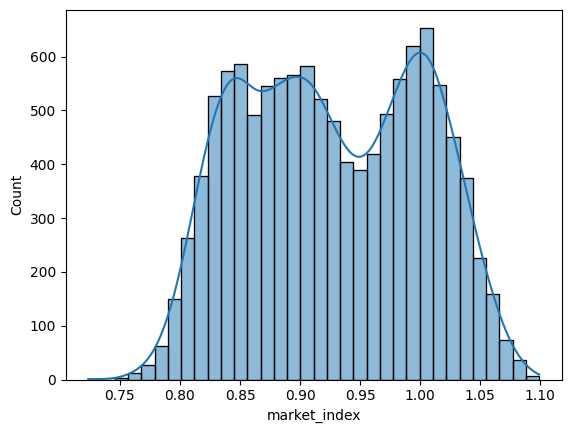

In [53]:
sns.histplot(valid['market_index'], kde=True)

In [54]:
# Same date feature extraction as train
valid['date'] = pd.to_datetime(valid['date'])
valid['month'] = valid['date'].dt.month
valid['day_of_week'] = valid['date'].dt.dayofweek
valid['days_since_start'] = (valid['date'] - pd.Timestamp('2025-01-01')).dt.days

# Same equipment one-hot encoding as train
valid = pd.get_dummies(valid, columns=['equipment'], prefix='equipment')

# Same imputation - USE THE MEDIANS FROM TRAIN, not valid's own median
market_index_mean = X_full['market_index'].mean()

valid['market_index'] = valid['market_index'].fillna(market_index_mean)


load_ids = valid['load_id']

# Droping the same columns i dropped  in train
valid_features = valid.drop(columns=[
    'load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
    'delivery_lat', 'delivery_lon', 'date'
])

In [55]:
valid_features = valid_features.reindex(columns=X_full.columns, fill_value=0)

print(valid_features.columns.tolist())
print(X_full.columns.tolist())

['distance', 'weight', 'market_index', 'quote_signal', 'month', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'day_of_week', 'days_since_start']
['distance', 'weight', 'market_index', 'quote_signal', 'month', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'day_of_week', 'days_since_start']


In [56]:
valid_features.describe()

,distance,weight,market_index,quote_signal,month,day_of_week,days_since_start
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,1141.773100,31279.182417,0.930160,2.051334,11.513667,2.996083,334.104500
std,732.333797,7882.996833,0.076654,0.219804,0.499834,2.022352,17.599476
min,70.000000,5000.000000,0.723610,1.234760,11.000000,0.000000,304.000000
25%,556.100000,25908.500000,0.865145,1.903467,11.000000,1.000000,319.000000
50%,953.600000,31323.500000,0.925930,2.051230,12.000000,3.000000,334.000000
75%,1670.500000,36769.500000,0.995648,2.200030,12.000000,5.000000,349.000000
max,3325.700000,47500.000000,1.098950,2.896350,12.000000,6.000000,364.000000


In [57]:
valid_features['predicted_rate'] = final_model.predict(valid_features)

submission = pd.DataFrame({
    'load_id': load_ids,
    'predicted_rate': valid_features['predicted_rate']
})

submission.to_csv('validation_predictions.csv', index=False)
submission.head()

,load_id,predicted_rate
0,TE-000001,857.995852
1,TE-000002,5095.446281
2,TE-000003,5597.044209
3,TE-000004,4315.352347
4,TE-000005,1793.869051


In [58]:
print(submission.shape)          # should be (12000, 2)
print(submission['load_id'].duplicated().sum())  # should be 0
print((submission['predicted_rate'] <= 0).sum())  # should be 0

(12000, 2)
0
0


#December Data

In [59]:
december=pd.read_csv("/content/drive/MyDrive/december-chart-inputs.csv",sep=',')

In [60]:
december['date'] = pd.to_datetime(december['date'])
december['month'] = december['date'].dt.month
december['day_of_week'] = december['date'].dt.dayofweek
december['days_since_start'] = (december['date'] - pd.Timestamp('2025-01-01')).dt.days

december_encoded = pd.get_dummies(december, columns=['equipment'], prefix='equipment',dtype=int)

december_encoded['weight'] = december_encoded['weight'].fillna(weight_median)
# market_index doesn't exist in this file — check columns first
print(december_encoded.columns.tolist())

['pickup', 'delivery', 'distance', 'weight', 'date', 'predicted_rate', 'month', 'day_of_week', 'days_since_start', 'equipment_Dry Van']


In [61]:
december_encoded

,pickup,delivery,distance,weight,date,predicted_rate,month,day_of_week,days_since_start,equipment_Dry Van
0,Lexington,Fort Wayne,360,32000,2025-12-01,NaN,12,0,334,1
1,Lexington,Fort Wayne,360,32000,2025-12-02,NaN,12,1,335,1
2,Lexington,Fort Wayne,360,32000,2025-12-03,NaN,12,2,336,1
3,Lexington,Fort Wayne,360,32000,2025-12-04,NaN,12,3,337,1
4,Lexington,Fort Wayne,360,32000,2025-12-05,NaN,12,4,338,1
5,Lexington,Fort Wayne,360,32000,2025-12-06,NaN,12,5,339,1
6,Lexington,Fort Wayne,360,32000,2025-12-07,NaN,12,6,340,1
7,Lexington,Fort Wayne,360,32000,2025-12-08,NaN,12,0,341,1
8,Lexington,Fort Wayne,360,32000,2025-12-09,NaN,12,1,342,1
9,Lexington,Fort Wayne,360,32000,2025-12-10,NaN,12,2,343,1


In [62]:
X_full

,distance,weight,market_index,quote_signal,month,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,day_of_week,days_since_start
load_id,,,,,,,,,,
TR-000017,1755.3,23493.0,0.96873,1.98336,1,0,0,1,2,0
TR-000130,1571.7,36231.0,0.93688,1.84064,1,1,0,0,2,0
TR-000131,1830.0,35777.0,0.98052,2.00431,1,0,1,0,2,0
TR-000132,2251.7,37379.0,1.00028,1.76503,1,1,0,0,2,0
TR-000133,483.5,9938.0,0.96622,2.12751,1,1,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...
TR-047999,1901.3,37581.0,1.00014,2.05132,10,0,1,0,4,303
TR-048000,2860.4,28359.0,1.07073,2.31578,10,1,0,0,4,303
TR-047969,1320.8,15582.0,0.97997,2.09042,10,0,1,0,4,303


In [63]:
# Get the average market_index and quote_signal for the most recent month in My data (October)
oct_data = X_full[X_full['month'] == 10]

recent_market_index = oct_data['market_index'].mean()
recent_quote_signal = oct_data['quote_signal'].mean()

print(recent_market_index, recent_quote_signal)

0.9585912058639396 1.942758493715228


In [64]:
oct_data

,distance,weight,market_index,quote_signal,month,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,day_of_week,days_since_start
load_id,,,,,,,,,,
TR-043302,84.4,29124.0,0.95071,0.80326,10,0,0,1,2,273
TR-043301,1056.2,35009.0,0.92546,1.81518,10,0,0,1,2,273
TR-043300,320.9,29026.0,0.94406,1.75786,10,1,0,0,2,273
TR-043299,1869.1,38731.0,0.94689,2.12214,10,0,1,0,2,273
TR-043306,1212.8,25756.0,0.88825,2.26441,10,1,0,0,2,273
...,...,...,...,...,...,...,...,...,...,...
TR-047999,1901.3,37581.0,1.00014,2.05132,10,0,1,0,4,303
TR-048000,2860.4,28359.0,1.07073,2.31578,10,1,0,0,4,303
TR-047969,1320.8,15582.0,0.97997,2.09042,10,0,1,0,4,303


In [65]:
december_encoded['market_index'] = recent_market_index
december_encoded['quote_signal'] = recent_quote_signal

In [66]:
december_encoded

,pickup,delivery,distance,weight,date,predicted_rate,month,day_of_week,days_since_start,equipment_Dry Van,market_index,quote_signal
0,Lexington,Fort Wayne,360,32000,2025-12-01,NaN,12,0,334,1,0.958591,1.942758
1,Lexington,Fort Wayne,360,32000,2025-12-02,NaN,12,1,335,1,0.958591,1.942758
2,Lexington,Fort Wayne,360,32000,2025-12-03,NaN,12,2,336,1,0.958591,1.942758
3,Lexington,Fort Wayne,360,32000,2025-12-04,NaN,12,3,337,1,0.958591,1.942758
4,Lexington,Fort Wayne,360,32000,2025-12-05,NaN,12,4,338,1,0.958591,1.942758
5,Lexington,Fort Wayne,360,32000,2025-12-06,NaN,12,5,339,1,0.958591,1.942758
6,Lexington,Fort Wayne,360,32000,2025-12-07,NaN,12,6,340,1,0.958591,1.942758
7,Lexington,Fort Wayne,360,32000,2025-12-08,NaN,12,0,341,1,0.958591,1.942758
8,Lexington,Fort Wayne,360,32000,2025-12-09,NaN,12,1,342,1,0.958591,1.942758
9,Lexington,Fort Wayne,360,32000,2025-12-10,NaN,12,2,343,1,0.958591,1.942758


In [67]:
# Drop non-feature columns
december_features = december_encoded.drop(columns=['pickup', 'delivery', 'date', 'predicted_rate'])

# Align exactly to training columns (fills missing equipment dummies with 0)
december_features = december_features.reindex(columns=X_full.columns, fill_value=0)

print(december_features.columns.tolist())
print(X_full.columns.tolist())
# must match exactly

['distance', 'weight', 'market_index', 'quote_signal', 'month', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'day_of_week', 'days_since_start']
['distance', 'weight', 'market_index', 'quote_signal', 'month', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'day_of_week', 'days_since_start']


In [68]:
december_features

,distance,weight,market_index,quote_signal,month,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,day_of_week,days_since_start
0,360,32000,0.958591,1.942758,12,1,0,0,0,334
1,360,32000,0.958591,1.942758,12,1,0,0,1,335
2,360,32000,0.958591,1.942758,12,1,0,0,2,336
3,360,32000,0.958591,1.942758,12,1,0,0,3,337
4,360,32000,0.958591,1.942758,12,1,0,0,4,338
5,360,32000,0.958591,1.942758,12,1,0,0,5,339
6,360,32000,0.958591,1.942758,12,1,0,0,6,340
7,360,32000,0.958591,1.942758,12,1,0,0,0,341
8,360,32000,0.958591,1.942758,12,1,0,0,1,342
9,360,32000,0.958591,1.942758,12,1,0,0,2,343


In [69]:
december_encoded['predicted_rate'] = final_model.predict(december_features)
december_encoded[['date', 'predicted_rate']].head()

,date,predicted_rate
0,2025-12-01,869.134547
1,2025-12-02,869.134547
2,2025-12-03,869.134547
3,2025-12-04,869.134547
4,2025-12-05,869.134547


In [70]:
december['predicted_rate'] = december_encoded['predicted_rate']
december['date'] = december['date'].dt.strftime('%Y-%m-%d')  # score.py expects a plain date string, not datetime
december = december.drop(columns=['month', 'day_of_week', 'days_since_start'])

december.to_csv('december_predictions.csv', index=False)
december.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,869.134547
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,869.134547
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,869.134547
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,869.134547
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,869.134547


In [71]:
print(december.columns.tolist())  # must be exactly: pickup, delivery, distance, equipment, weight, date, predicted_rate
print(december['predicted_rate'].isna().sum())  # 0
print((december['predicted_rate'] <= 0).sum())  # 0

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
0
0


In [72]:
!python score.py --predictions validation_predictions.csv --december-predictions december_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


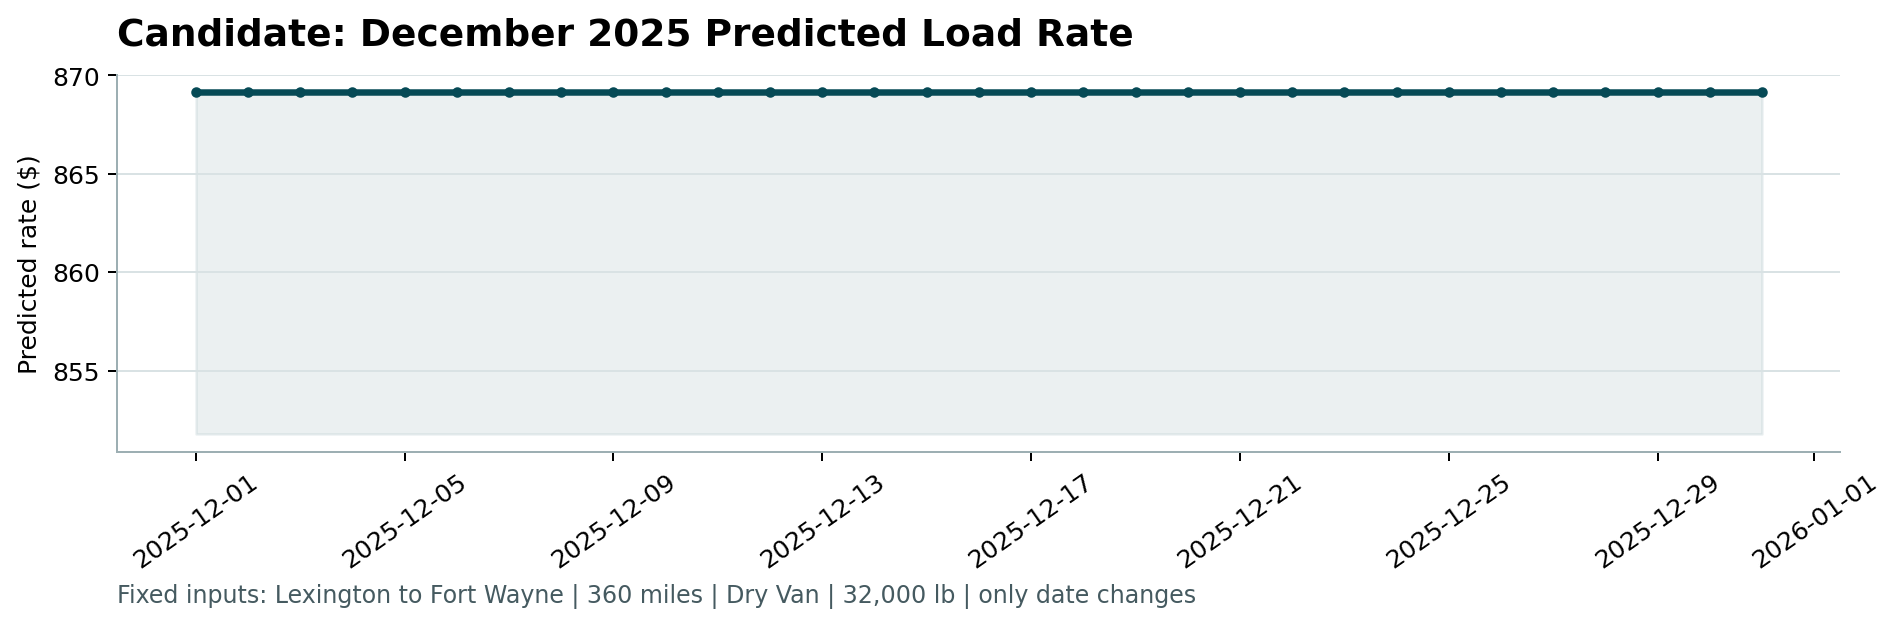

In [73]:
from IPython.display import Image
Image('scorer_results/candidate_december.png')